In [ ]:
!pip install transformers datasets torch torchvision evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 848.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from PIL import Image
from sklearn.model_selection import train_test_split

# Define the path to your OCT dataset
data_path = "/content/drive/MyDrive/OCTDL"  # Replace with your OCT dataset path in Google Drive

# Define the image loader function for OCT images
def img_loader(path):
    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert('RGB')

# Define a custom dataset class for loading OCT images
class CustomizedImageFolder:
    def __init__(self, root, transform=None, target_transform=None, loader=img_loader):
        self.root = root
        self.transform = transform
        self.target_transform = target_transform
        self.loader = loader
        self.samples = []
        self.classes = sorted(os.listdir(root))  # Assuming subfolders represent classes
        for class_idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(root, class_name)
            if os.path.isdir(class_dir):
                for img_name in os.listdir(class_dir):
                    img_path = os.path.join(class_dir, img_name)
                    if img_path.endswith(('.jpg', '.jpeg', '.png')):
                        self.samples.append((img_path, class_idx))

    def __getitem__(self, index):
        path, target = self.samples[index]
        sample = self.loader(path)
        if self.transform:
            sample = self.transform(sample)
        if self.target_transform:
            target = self.target_transform(target)
        return sample, target

    def __len__(self):
        return len(self.samples)

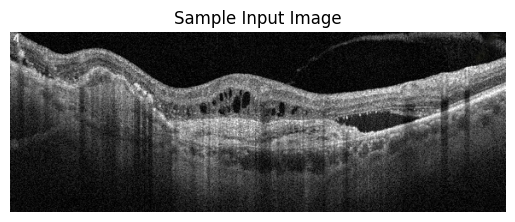

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split # Make sure to import this

# Assuming 'CustomizedImageFolder' and 'data_path' are defined in previous cells

# Instantiate the dataset
dataset = CustomizedImageFolder(data_path)

# Split the dataset into train and test sets
train_samples, valid_samples = train_test_split(dataset.samples, test_size=0.1, random_state=42)
train_samples, test_samples = train_test_split(train_samples, test_size=0.1, random_state=42)


# Now you can access train_samples
sample_image = train_samples[0][0]  # Path to the image file

# Load and display the image
img = Image.open(sample_image)
plt.imshow(img)
plt.axis('off')  # Hide axes for a cleaner look
plt.title("Sample Input Image")
plt.show()



In [ ]:
from torchvision.transforms import RandomResizedCrop, RandomHorizontalFlip, Compose, Normalize, ToTensor
from transformers import AutoImageProcessor

# Load the image processor for ViT
# checkpoint = 'microsoft/beit-base-patch16-224-pt22k-ft22k'  # Change to ViT checkpoint
checkpoint = 'google/vit-base-patch16-224-in21k'
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

# Define image transformations for OCT data
normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)

size = (image_processor.size["shortest_edge"]
        if "shortest_edge" in image_processor.size
        else (image_processor.size["height"], image_processor.size["width"]))

_transforms = Compose([RandomResizedCrop(size), RandomHorizontalFlip(0.5), ToTensor(), normalize])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [ ]:
from PIL import Image

# Preprocessing function for OCT images
def transforms(examples):
    # Load images before applying transforms
    examples["pixel_values"] = [
        _transforms(Image.open(img).convert("RGB"))  # Open and convert to RGB
        for img in examples["image"]
    ]
    del examples["image"]
    return examples

In [ ]:
from datasets import Dataset, DatasetDict

# Load OCT dataset (ensure the path points to your dataset)
full_dataset = CustomizedImageFolder(data_path, transform=_transforms)

# Convert to Dataset format
train_dataset = Dataset.from_dict({
    "image": [img for img, _ in train_samples],
    "label": [label for _, label in train_samples]
})

valid_dataset = Dataset.from_dict({
    "image": [img for img, _ in valid_samples],
    "label": [label for _, label in valid_samples]
})

test_dataset = Dataset.from_dict({
    "image": [img for img, _ in test_samples],
    "label": [label for _, label in test_samples]
})

# Create DatasetDict
dataset = DatasetDict({
    "train": train_dataset,
    "valid": valid_dataset,
    "test": test_dataset
})

# Apply transformations
dataset = dataset.with_transform(transforms)

# Get class labels (subfolders represent classes)
labels = full_dataset.classes

# Create label mappings
label2id = {label: str(i) for i, label in enumerate(labels)}
id2label = {str(i): label for i, label in enumerate(labels)}



In [ ]:
id2label

{'0': 'AMD',
 '1': 'DME',
 '2': 'ERM',
 '3': 'NO',
 '4': 'RAO',
 '5': 'RVO',
 '6': 'VID',
 '7': 'beit_actual.npy',
 '8': 'beit_logits.npy',
 '9': 'confusion_matrix.png'}

In [ ]:
label2id

{'AMD': '0',
 'DME': '1',
 'ERM': '2',
 'NO': '3',
 'RAO': '4',
 'RVO': '5',
 'VID': '6',
 'beit_actual.npy': '7',
 'beit_logits.npy': '8',
 'confusion_matrix.png': '9'}

In [ ]:
labels

['AMD',
 'DME',
 'ERM',
 'NO',
 'RAO',
 'RVO',
 'VID',
 'beit_actual.npy',
 'beit_logits.npy',
 'confusion_matrix.png']

In [ ]:
from transformers import AutoModelForImageClassification

# Load model for image classification
model = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments, EarlyStoppingCallback

# Define training arguments
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/OCTDL/output",  # Modify the model save directory
    remove_unused_columns=False,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    weight_decay=0.01,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=16,
    num_train_epochs=60,
    warmup_ratio=0.1,
    logging_steps=10,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    push_to_hub=False,
    report_to="none",
)





In [ ]:
from transformers import Trainer
from transformers import DefaultDataCollator
import evaluate
import numpy as np

# Define metric computation (accuracy)
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

# Data collator for padding
data_collator = DefaultDataCollator()

# Set up Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=dataset["train"],
    eval_dataset=dataset["valid"],
    compute_metrics=compute_metrics,
)


In [ ]:
# Train the model
trainer.train()
training_log = trainer.state.log_history

Epoch,Training Loss,Validation Loss


In [ ]:
# Evaluate the model
results = trainer.evaluate(dataset["test"])
print(results)


{'eval_loss': 0.6001733541488647, 'eval_accuracy': 0.8695652173913043, 'eval_runtime': 67.8193, 'eval_samples_per_second': 3.052, 'eval_steps_per_second': 0.192, 'epoch': 49.523809523809526}


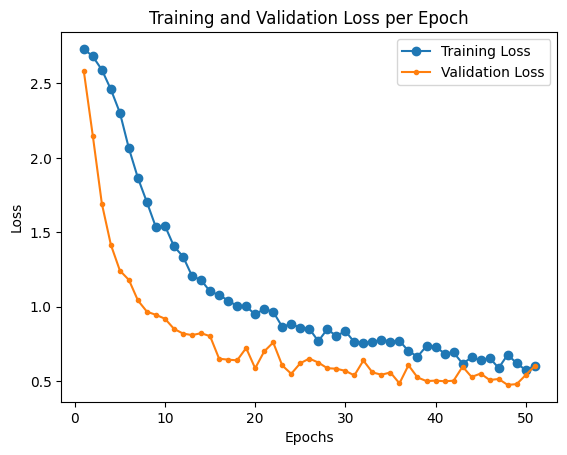

In [ ]:
import matplotlib.pyplot as plt

# Extract loss values from the log history
train_loss = [entry["loss"] for entry in training_log if "loss" in entry]
eval_loss = [entry["eval_loss"] for entry in training_log if "eval_loss" in entry]

# Generate epochs based on the length of eval_loss to match dimensions
epochs = range(1, len(eval_loss) + 1)  # Use len(eval_loss) for x-axis

# Plot the loss curves
# plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss[:len(eval_loss)], label="Training Loss", marker='o') # Truncate train_loss to match eval_loss length
plt.plot(epochs, eval_loss, label="Validation Loss", marker='.')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.show()

In [ ]:
# Get predictions using the model's predict method
predictions = trainer.predict(dataset["test"])

# Predicted labels are in predictions.predictions
prediction = np.argmax(predictions.predictions, axis=1)
actual = np.array(dataset["test"][:]['label'])  # Ground-truth labels
print(f'Predictions: {prediction[:10]}')
print(f'Actual: {actual[:10]}')

# Save predictions for stacking
import numpy as np

# Save the logits (raw model outputs before argmax)
np.save("/content/drive/MyDrive/OCTDL/beit_logits.npy", predictions.predictions)  # Replace 'beit' for each model

# Save the actual labels for stacking
np.save("/content/drive/MyDrive/OCTDL/beit_actual.npy", actual)

Predictions: [2 2 2 2 2 2 7 2 3 2]
Actual: [5 2 2 2 2 2 3 2 3 2]


In [ ]:
label_names = ['AMD','DME','ERM','NO','RAO','RVO','VID']
label_names = np.array(label_names)

In [ ]:
from sklearn.metrics import classification_report
classification_report(actual, prediction,target_names=label_names,digits=4)

'              precision    recall  f1-score   support\n\n         AMD     0.9402    0.9565    0.9483       115\n         DME     0.7500    0.8333    0.7895        18\n         ERM     0.8462    0.7857    0.8148        14\n          NO     0.7727    0.9189    0.8395        37\n         RAO     1.0000    0.2500    0.4000         4\n         RVO     0.6667    0.5000    0.5714         8\n         VID     0.6667    0.3636    0.4706        11\n\n    accuracy                         0.8647       207\n   macro avg     0.8061    0.6583    0.6906       207\nweighted avg     0.8634    0.8647    0.8555       207\n'

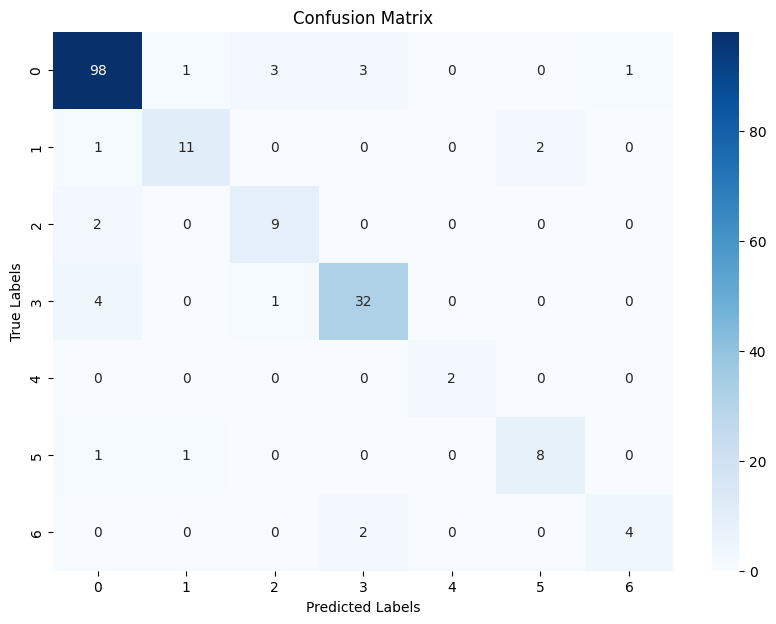

In [ ]:

from sklearn.metrics import confusion_matrix
import seaborn as sns

sns.heatmap(confusion_matrix(actual, prediction), annot = True,
            cmap="blues", xticklabels=label_names, yticklabels=label_names)